**Arabic AI detection Using Machine Learning Techniques**

## **Part 1: Cleaning**

In [ ]:
import re
import pandas as pd
import nltk

nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.stem.isri import ISRIStemmer

arabic_stopwords = stopwords.words('arabic')
stemmer = ISRIStemmer()
merged = pd.read_csv('merged_dataset.csv', encoding='utf-8-sig')

def normalize(text):

    # reduce repeated letters (هههههه → ه)
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # keep Arabic characters and spaces only
    text = re.sub(r'[^\u0620-\u065F\s]', ' ', text)

    # normalize Arabic variants
    text = text.replace('أ', 'ا')
    text = text.replace('إ', 'ا')
    text = text.replace('آ', 'ا')
    text = text.replace('ى', 'ي')
    text = text.replace('ؤ', 'و')
    text = text.replace('ئ', 'ي')
    text = text.replace('ة', 'ه')

    # remove tatweel
    text = text.replace('ـ', '')

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


def preprocess(text):
    if pd.isna(text):
        return ''

    text = normalize(str(text))

    words = [
        w for w in text.split()
        if w not in arabic_stopwords
    ]

    stemmed = [
        stemmer.stem(word)
        for word in words
    ]

    return ' '.join(stemmed)


# Apply preprocessing
merged['text_normalized'] = (
    merged['text']
    .apply(preprocess)
)

# Remove duplicates
merged.drop_duplicates(
    subset=['text_normalized'],
    inplace=True
)

# Remove very short texts (<=10 chars)
merged = merged[
    merged['text_normalized']
    .str.strip()
    .str.len() > 10
]

merged.to_csv('final_preprocessed.csv', index=False, encoding='utf-8-sig')
merged.info(), display(merged.head()), merged['label'].value_counts()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


<class 'pandas.core.frame.DataFrame'>
Index: 1700 entries, 0 to 1812
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   text             1700 non-null   object
 1   label            1700 non-null   object
 2   source           1700 non-null   object
 3   text_normalized  1700 non-null   object
dtypes: object(4)
memory usage: 66.4+ KB


,text,label,source,text_normalized
0,يعتبر نمط الحياة الصحي ركيزة أساسية لتحقيق الت...,AI,Unknown AI,عبر نمط حيه صحي ركز سسي حقق وزن جسد نفس قصر فق...
1,إن نمط الحياة الصحي لا يقتصر بأي حال من الأحوا...,AI,Unknown AI,ان نمط حيه صحي قصر باي حال حول علي عني جنب بدن...
2,يلعب شرب الماء بكميات كافية والحصول على قسط وا...,AI,Unknown AI,لعب شرب ماء بكم كفي حصل علي قسط وفر نوم دور حي...
3,يمثل الطب الوقائي وإجراء الفحوصات الطبية الدور...,AI,Unknown AI,مثل لطب وقي جرء فحص طبه دور حجر زوي حفظ علي نم...
4,التغذية السليمة هي الوقود الحقيقي الذي يدفع عج...,AI,Unknown AI,غذه سلم وقد حقق دفع عجل حيه صحه يمكن تصر نمط ح...


(None,
 None,
 label
 Human    851
 AI       849
 Name: count, dtype: int64)

## **Part 2: Text Representation**

In [ ]:
#!pip install gensim scikit-learn torch transformers arabert

In [ ]:
import numpy as np
import pandas as pd
from scipy import sparse

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from gensim.models import Word2Vec

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
INPUT_CSV  = "final_preprocessed.csv"
TEXT_COL   = "text_normalized"   # preprocessed Arabic text
LABEL_COL  = "label"

# Word2Vec hyperparameters
W2V_DIM     = 300    # embedding dimension
W2V_WINDOW  = 5      # context window size
W2V_MIN     = 2      # ignore words that appear fewer than this many times
W2V_EPOCHS  = 15     # training epochs
W2V_SG      = 1      # 1 = Skip-Gram (better for rare words), 0 = CBOW


In [ ]:
def load_data(path):
    print("=" * 60)
    print("Loading data")
    print("=" * 60)

    df = merged.copy()  # load from preprocessed DataFrame instead of CSV for this example

    # Drop rows where normalized text is missing
    df = df[df[TEXT_COL].notna() & (df[TEXT_COL].str.strip() != "")]
    df = df.reset_index(drop=True)

    texts  = df[TEXT_COL].tolist()
    labels = df[LABEL_COL].tolist()

    print(f"  Total samples : {len(texts)}")
    print(f"  Label dist    : {pd.Series(labels).value_counts().to_dict()}")
    print(f"  Avg tokens    : {np.mean([len(t.split()) for t in texts]):.1f}")

    # Encode labels: AI=0, Human=1
    le = LabelEncoder()
    y  = le.fit_transform(labels)
    print(f"  Label mapping : {dict(zip(le.classes_, le.transform(le.classes_)))}")

    return texts, y, le


def save_all(bow_matrix, tfidf_matrix, w2v_matrix, w2v_model, y):
    print("\n" + "=" * 60)
    print("Saving representations")
    print("=" * 60)

    sparse.save_npz("bow_matrix.npz",   bow_matrix)
    sparse.save_npz("tfidf_matrix.npz", tfidf_matrix)
    np.save("w2v_matrix.npy",           w2v_matrix)
    np.save("labels.npy",               y)
    w2v_model.save("w2v_model.model")

    print("  Saved: bow_matrix.npz")
    print("  Saved: tfidf_matrix.npz")
    print("  Saved: w2v_matrix.npy")
    print("  Saved: labels.npy")
    print("  Saved: w2v_model.model")



def print_comparison(bow_matrix, tfidf_matrix, w2v_matrix):
    print("\n" + "=" * 60)
    print("COMPARISON SUMMARY")
    print("=" * 60)

    bow_density   = bow_matrix.nnz   / np.prod(bow_matrix.shape)   * 100
    tfidf_density = tfidf_matrix.nnz / np.prod(tfidf_matrix.shape) * 100

    print(f"  {'Method':<12} {'Shape':<22} {'Type':<10} {'Density'}")
    print(f"  {'-'*58}")
    print(f"  {'BoW':<12} {str(bow_matrix.shape):<22} {'Sparse':<10} {bow_density:.2f}%")
    print(f"  {'TF-IDF':<12} {str(tfidf_matrix.shape):<22} {'Sparse':<10} {tfidf_density:.2f}%")
    print(f"  {'Word2Vec':<12} {str(w2v_matrix.shape):<22} {'Dense':<10} 100.00%")

    print("""
  Key differences:
  ┌─────────────┬────────────────────────────────────────────────────┐
  │ BoW         │ Raw word counts. Fast, simple, ignores word order. │
  │             │ High-dimensional sparse vectors.                   │
  ├─────────────┼────────────────────────────────────────────────────┤
  │ TF-IDF      │ Weighted counts. Penalizes common words, rewards   │
  │             │ distinctive ones. Includes bigrams.                │
  ├─────────────┼────────────────────────────────────────────────────┤
  │ Word2Vec    │ Dense semantic vectors. Captures meaning and word  │
  │             │ relationships. Best for neural models.             │
  └─────────────┴────────────────────────────────────────────────────┘
    """)




In [ ]:
def build_bow(texts):
    """
    Bag-of-Words:
    - Each text becomes a vector of word counts.
    - Vocabulary built from the entire corpus.
    - max_features=10000 keeps only the 10k most frequent words.
    - Output: sparse matrix of shape (n_samples, vocab_size)
    """
    print("\n" + "=" * 60)
    print("REPRESENTATION 1: Bag-of-Words (BoW)")
    print("=" * 60)

    vectorizer = CountVectorizer(
        max_features=10_000,   # top 10k most frequent words
        min_df=2,              # ignore words appearing in fewer than 2 docs
        max_df=0.95,           # ignore words appearing in more than 95% of docs
        analyzer="word",
        token_pattern=r"[\u0600-\u06FF]+"  # Arabic characters only
    )

    bow_matrix = vectorizer.fit_transform(texts)

    vocab      = vectorizer.get_feature_names_out()
    print(f"  Vocabulary size : {len(vocab)}")
    print(f"  Matrix shape    : {bow_matrix.shape}")
    print(f"  Matrix density  : {bow_matrix.nnz / np.prod(bow_matrix.shape) * 100:.2f}%")
    print(f"  Top 10 words    : {list(vocab[:10])}")

    return bow_matrix, vectorizer


In [ ]:
def build_tfidf(texts):
    """
    TF-IDF (Term Frequency - Inverse Document Frequency):
    - Weights words by how important they are to a document
      relative to the whole corpus.
    - Common words get lower weight; rare distinctive words get higher weight.
    - Also extracts bigrams (2-word phrases) in addition to unigrams.
    - Output: sparse matrix of shape (n_samples, vocab_size)
    """
    print("\n" + "=" * 60)
    print("REPRESENTATION 2: TF-IDF")
    print("=" * 60)

    vectorizer = TfidfVectorizer(
        max_features=10_000,
        min_df=2,
        max_df=0.95,
        ngram_range=(1, 2),                # unigrams + bigrams
        sublinear_tf=True,                 # apply log normalization to TF
        analyzer="word",
        token_pattern=r"[\u0600-\u06FF]+"  # Arabic characters only
    )

    tfidf_matrix = vectorizer.fit_transform(texts)

    vocab = vectorizer.get_feature_names_out()
    print(f"  Vocabulary size : {len(vocab)}")
    print(f"  Matrix shape    : {tfidf_matrix.shape}")
    print(f"  Matrix density  : {tfidf_matrix.nnz / np.prod(tfidf_matrix.shape) * 100:.2f}%")
    print(f"  Top 10 features : {list(vocab[:10])}")

    # Show highest TF-IDF scoring terms overall
    mean_scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
    top_idx     = mean_scores.argsort()[::-1][:10]
    print(f"  Highest avg TF-IDF terms: {[vocab[i] for i in top_idx]}")

    return tfidf_matrix, vectorizer


In [ ]:
def build_word2vec(texts):
    """
    Word2Vec — averaged document embeddings:
    - Trains a Skip-Gram Word2Vec model on our corpus.
    - Each word gets a dense 300-dimensional vector.
    - Each document is represented as the average of its word vectors.
    - Output: dense matrix of shape (n_samples, W2V_DIM)

    Why Skip-Gram (sg=1)?
    - Better at representing rare/low-frequency words.
    - More suitable for our dataset size (~1600 docs).
    """
    print("\n" + "=" * 60)
    print("REPRESENTATION 3: Word2Vec (Skip-Gram, 300-dim)")
    print("=" * 60)

    # Tokenize: each text → list of words
    tokenized = [text.split() for text in texts]

    print(f"  Training Word2Vec on {len(tokenized)} sentences...")
    model = Word2Vec(
        sentences  = tokenized,
        vector_size= W2V_DIM,
        window     = W2V_WINDOW,
        min_count  = W2V_MIN,
        workers    = 4,
        epochs     = W2V_EPOCHS,
        sg         = W2V_SG
    )

    vocab_size = len(model.wv)
    print(f"  Vocabulary size : {vocab_size}")
    print(f"  Vector dim      : {W2V_DIM}")

    # Build document vectors by averaging word vectors
    def doc_vector(tokens):
        """Average the vectors of all known words in a document."""
        vecs = [
            model.wv[word]
            for word in tokens
            if word in model.wv
        ]
        if vecs:
            return np.mean(vecs, axis=0)
        else:
            return np.zeros(W2V_DIM)   # fallback for empty docs

    w2v_matrix = np.array([doc_vector(tokens) for tokens in tokenized])

    print(f"  Document matrix shape : {w2v_matrix.shape}")
    print(f"  Non-zero rows         : {np.sum(w2v_matrix.any(axis=1))}")

    # Show a semantic similarity example
    test_word = "الذكاء"
    if test_word in model.wv:
        similar = model.wv.most_similar(test_word, topn=5)
        print(f"\n  Semantic check — most similar to '{test_word}':")
        for word, score in similar:
            print(f"    {word:<20} {score:.4f}")

    return w2v_matrix, model


In [ ]:
def load_pretrained_word2vec(model_path, texts):
    """
    Use a pre-trained Arabic Word2Vec model (AraVec or fastText)
    instead of training from scratch.

    HOW TO USE ARAVEC:
    ------------------
    1. Download from: https://github.com/bakrianoo/aravec
       Recommended: 'full_uni_cbow_300_twitter.zip' (Twitter, 300-dim, CBOW)
    2. Unzip and place the .model file in the same folder as this script.
    3. Call this function:
         w2v_matrix, model = load_pretrained_word2vec("full_uni_cbow_300_twitter.model", texts)

    HOW TO USE FASTTEXT ARABIC:
    ---------------------------
    1. Download: https://fasttext.cc/docs/en/crawl-vectors.html
       File: cc.ar.300.bin.gz  (~4 GB)
    2. pip install fasttext
    3. Use this instead:
         import fasttext
         ft_model = fasttext.load_model("cc.ar.300.bin")
         w2v_matrix = np.array([ft_model.get_sentence_vector(t) for t in texts])
    """
    from gensim.models import KeyedVectors, Word2Vec as W2V

    print(f"  Loading pre-trained model from: {model_path}")
    w2v_matrix, model = load_pretrained_word2vec("full_uni_cbow_300_twitter.model", texts)

    # Try loading as KeyedVectors (.bin) or full model (.model)
    try:
        wv = KeyedVectors.load_word2vec_format(model_path, binary=True)
    except Exception:
        wv = W2V.load(model_path).wv

    tokenized = [text.split() for text in texts]

    def doc_vector(tokens):
        vecs = [wv[w] for w in tokens if w in wv]
        return np.mean(vecs, axis=0) if vecs else np.zeros(wv.vector_size)

    w2v_matrix = np.array([doc_vector(t) for t in tokenized])
    print(f"  Pre-trained W2V matrix shape: {w2v_matrix.shape}")
    return w2v_matrix, wv


# ═══════════════════════════════════════════════════════
# MAIN
# ═══════════════════════════════════════════════════════

# Load
texts, y, label_encoder = load_data(INPUT_CSV)

# Build representations
bow_matrix,   bow_vectorizer   = build_bow(texts)
tfidf_matrix, tfidf_vectorizer = build_tfidf(texts)
w2v_matrix,   w2v_model        = build_word2vec(texts)

# Summary
print_comparison(bow_matrix, tfidf_matrix, w2v_matrix)

# Save
save_all(bow_matrix, tfidf_matrix, w2v_matrix, w2v_model, y)

print("\nAll representations ready for Part 4 (Classical ML Models).")
print("Load them in Part 4 with:")
print("  from scipy.sparse import load_npz")
print("  bow_matrix   = load_npz('bow_matrix.npz')")
print("  tfidf_matrix = load_npz('tfidf_matrix.npz')")
print("  w2v_matrix   = np.load('w2v_matrix.npy')")
print("  y            = np.load('labels.npy')")


Loading data
  Total samples : 1700
  Label dist    : {'Human': 851, 'AI': 849}
  Avg tokens    : 123.1
  Label mapping : {np.str_('AI'): np.int64(0), np.str_('Human'): np.int64(1)}

REPRESENTATION 1: Bag-of-Words (BoW)
  Vocabulary size : 3640
  Matrix shape    : (1700, 3640)
  Matrix density  : 2.44%
  Top 10 words    : ['اال', 'اب', 'ابء', 'ابد', 'ابض', 'ابع', 'ابل', 'ابن', 'ابي', 'اتت']

REPRESENTATION 2: TF-IDF
  Vocabulary size : 10000
  Matrix shape    : (1700, 10000)
  Matrix density  : 1.34%
  Top 10 features : ['اب', 'ابء', 'ابد', 'ابض', 'ابن', 'ابي', 'اتح', 'اتح عرف', 'اتح فرص', 'اتح وصل']
  Highest avg TF-IDF terms: ['علي', 'علم', 'ان', 'ذكء', 'الي', 'صطناع', 'خدم', 'ذكء صطناع', 'عمل', 'شكل']

REPRESENTATION 3: Word2Vec (Skip-Gram, 300-dim)
  Training Word2Vec on 1700 sentences...
  Vocabulary size : 3747
  Vector dim      : 300
  Document matrix shape : (1700, 300)
  Non-zero rows         : 1700

COMPARISON SUMMARY
  Method       Shape                  Type       Density
 

## **Part 3: Classical ML and Neural Networks Models**

In [ ]:
#  !pip install torch transformers arabert gensim scikit-learn

In [ ]:
import os
import gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig
from arabert.preprocess import ArabertPreprocessor
import gensim

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_DIR = "saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

def free_gpu():
    gc.collect()
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    if torch.cuda.is_available():
        free = torch.cuda.mem_get_info()[0] / 1e9
        print(f"  GPU free: {free:.2f} GB")

le = LabelEncoder()
y_enc = le.fit_transform(y)
y6 = y_enc

X_tfidf_dense = tfidf_matrix.toarray() if hasattr(tfidf_matrix, 'toarray') else tfidf_matrix
X_bow_dense = bow_matrix.toarray() if hasattr(bow_matrix, 'toarray') else bow_matrix
X_w2v_dense = w2v_matrix.toarray() if hasattr(w2v_matrix, 'toarray') else w2v_matrix
texts = merged['text'].values

# AraVec Embeddings
ARAVEC_PATH = 'aravec/tweets_cbow_300'
aravec = gensim.models.Word2Vec.load(ARAVEC_PATH)
DIM = aravec.wv.vector_size

def text_to_vec(texts, model, dim=DIM):
    vecs = []
    for t in texts:
        toks = [w for w in str(t).split() if w in model.wv]
        vecs.append(np.mean([model.wv[w] for w in toks], axis=0) if toks else np.zeros(dim))
    return np.array(vecs, dtype=np.float32)

X_aravec = text_to_vec(texts, aravec)

# 2. Deep Learning Base Architectures
class FNN(nn.Module):
    def __init__(self, inp):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(inp, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 128), nn.ReLU(), nn.Linear(128, 2)
        )
    def forward(self, x):
        return self.net(x)

class LSTMClassifier(nn.Module):
    def __init__(self, inp):
        super().__init__()
        self.lstm = nn.LSTM(inp, 128, batch_first=True, bidirectional=True)
        self.fc   = nn.Linear(256, 2)
    def forward(self, x):
        out, _ = self.lstm(x.unsqueeze(1))
        return self.fc(out[:, -1])

# ── 3. Sklearn Wrappers for Saving & Loading ───────────────────────────────────
class PyTorchSklearnWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model_class, input_dim, name, epochs=5, bs=64, lr=1e-3):
        self.model_class = model_class
        self.input_dim = input_dim
        self.name = name
        self.epochs = epochs
        self.bs = bs
        self.lr = lr
        self.fold_counter = 0

    def fit(self, X, y):
        self.fold_counter += 1
        model = self.model_class(self.input_dim).to(DEVICE)
        ds = TensorDataset(torch.FloatTensor(X), torch.LongTensor(y))
        dl = DataLoader(ds, batch_size=self.bs, shuffle=True)
        opt = torch.optim.Adam(model.parameters(), lr=self.lr)
        loss_fn = nn.CrossEntropyLoss()

        model.train()
        for _ in range(self.epochs):
            for xb, yb in dl:
                opt.zero_grad()
                loss_fn(model(xb.to(DEVICE)), yb.to(DEVICE)).backward()
                opt.step()

        # Save model locally
        save_path = os.path.join(SAVE_DIR, f"{self.name}_fold{self.fold_counter}.pt")
        torch.save(model.state_dict(), save_path)

        del model
        free_gpu()
        return self

    def predict(self, X):
        # Load model locally
        save_path = os.path.join(SAVE_DIR, f"{self.name}_fold{self.fold_counter}.pt")
        model = self.model_class(self.input_dim).to(DEVICE)
        model.load_state_dict(torch.load(save_path))
        model.eval()

        ds = TensorDataset(torch.FloatTensor(X))
        dl = DataLoader(ds, batch_size=self.bs, shuffle=False)
        preds = []

        with torch.no_grad():
            for xb in dl:
                logits = model(xb[0].to(DEVICE))
                preds.extend(logits.argmax(1).cpu().numpy())

        del model
        free_gpu()
        return np.array(preds)

class TransformerSklearnWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model_name, name, epochs=5, bs=16, max_len=128):
        self.model_name = model_name
        self.name = name
        self.epochs = epochs
        self.bs = bs
        self.max_len = max_len
        self.fold_counter = 0

    def fit(self, X, y):
        self.fold_counter += 1
        prep = ArabertPreprocessor(model_name=self.model_name, keep_emojis=False)
        tok = AutoTokenizer.from_pretrained(self.model_name, use_fast=True)
        X_clean = [prep.preprocess(str(t)) for t in X]

        cfg = AutoConfig.from_pretrained(self.model_name, num_labels=2)
        model = AutoModelForSequenceClassification.from_pretrained(
                self.model_name, config=cfg, ignore_mismatched_sizes=True).to(DEVICE)

        opt = torch.optim.AdamW(model.parameters(), lr=2e-5)
        y_tensor = torch.LongTensor(y).to(DEVICE)

        model.train()
        for _ in range(self.epochs):
            for b in range(0, len(X_clean), self.bs):
                batch_texts = X_clean[b:b+self.bs]
                batch = tok(batch_texts, padding=True, truncation=True, max_length=self.max_len, return_tensors='pt').to(DEVICE)
                out = model(**batch, labels=y_tensor[b:b+self.bs])
                out.loss.backward()
                opt.step()
                opt.zero_grad()

        # Save model and tokenizer locally
        save_path = os.path.join(SAVE_DIR, f"{self.name}_fold{self.fold_counter}")
        model.save_pretrained(save_path)
        tok.save_pretrained(save_path)

        del model, tok
        free_gpu()
        return self

    def predict(self, X):
        # Load locally
        save_path = os.path.join(SAVE_DIR, f"{self.name}_fold{self.fold_counter}")
        prep = ArabertPreprocessor(model_name=self.model_name, keep_emojis=False)
        tok = AutoTokenizer.from_pretrained(save_path)
        model = AutoModelForSequenceClassification.from_pretrained(save_path).to(DEVICE)
        model.eval()

        X_clean = [prep.preprocess(str(t)) for t in X]
        preds = []

        with torch.no_grad():
            for b in range(0, len(X_clean), self.bs):
                batch = tok(X_clean[b:b+self.bs], padding=True, truncation=True, max_length=self.max_len, return_tensors='pt').to(DEVICE)
                logits = model(**batch).logits
                preds.extend(logits.argmax(1).cpu().tolist())

        del model, tok
        free_gpu()
        return np.array(preds)


# 4. Unified Models Dictionary
# We map the model to the exact feature dataset it requires (Model, Data)
MODELS6 = {
    # === Classical ML with TF-IDF (Already in your code) ===
    'Naive Bayes TF-IDF':         (MultinomialNB(), X_tfidf_dense),
    'Logistic Regression TF-IDF': (LogisticRegression(max_iter=1000, random_state=42), X_tfidf_dense),
    'Decision Tree TF-IDF':       (DecisionTreeClassifier(random_state=42), X_tfidf_dense),
    'SVM TF-IDF':                 (SVC(kernel='linear', probability=True, random_state=42), X_tfidf_dense),
    'Random Forest TF-IDF':       (RandomForestClassifier(random_state=42), X_tfidf_dense),
    'AdaBoost TF-IDF':            (AdaBoostClassifier(random_state=42), X_tfidf_dense),

    # === Classical ML with Bag-of-Words (BOW) ===
    'Naive Bayes BOW':         (MultinomialNB(), X_bow_dense),
    'Logistic Regression BOW': (LogisticRegression(max_iter=1000, random_state=42), X_bow_dense),
    'Decision Tree BOW':       (DecisionTreeClassifier(random_state=42), X_bow_dense),
    'SVM BOW':                 (SVC(kernel='linear', probability=True, random_state=42), X_bow_dense),
    'Random Forest BOW':       (RandomForestClassifier(random_state=42), X_bow_dense),
    'AdaBoost BOW':            (AdaBoostClassifier(random_state=42), X_bow_dense),

    # === Classical ML with Word2Vec (w2v) ===
    'Naive Bayes Word2Vec':         (GaussianNB(), X_w2v_dense), # Uses GaussianNB because Word2Vec has negative values
    'Logistic Regression Word2Vec': (LogisticRegression(max_iter=1000, random_state=42), X_w2v_dense),
    'Decision Tree Word2Vec':       (DecisionTreeClassifier(random_state=42), X_w2v_dense),
    'SVM Word2Vec':                 (SVC(kernel='linear', probability=True, random_state=42), X_w2v_dense),
    'Random Forest Word2Vec':       (RandomForestClassifier(random_state=42), X_w2v_dense),
    'AdaBoost Word2Vec':            (AdaBoostClassifier(random_state=42), X_w2v_dense),

    # 6 Deep Learning/Transformer models integrated perfectly
    'FNN TF-IDF':          (PyTorchSklearnWrapper(FNN, X_tfidf_dense.shape[1], 'FNN_TFIDF'), X_tfidf_dense),
    'LSTM TF-IDF':         (PyTorchSklearnWrapper(LSTMClassifier, X_tfidf_dense.shape[1], 'LSTM_TFIDF'), X_tfidf_dense),
    'FNN AraVec3':         (PyTorchSklearnWrapper(FNN, DIM, 'FNN_AraVec3'), X_aravec),
    'LSTM AraVec3':        (PyTorchSklearnWrapper(LSTMClassifier, DIM, 'LSTM_AraVec3'), X_aravec),
    'AraBERT':             (TransformerSklearnWrapper('aubmindlab/bert-base-arabertv02', 'AraBERT'), texts),
    'MARBERTv2':           (TransformerSklearnWrapper('UBC-NLP/MARBERTv2', 'MARBERTv2'), texts),
}

# 5. 5-fold CV – Collect per-sample predictions
skf6 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model_preds6 = {}

df_eval = pd.DataFrame({'y_true': y6})

for mname, (base_model, X_data) in MODELS6.items():
    print(f"Training & Evaluating: {mname}...")
    all_preds = np.zeros(len(y6), dtype=int)

    # Reset fold counter for neural models
    if hasattr(base_model, 'fold_counter'):
        base_model.fold_counter = 0

    for tr, te in skf6.split(X_data, y6):
        # Neural wrappers handle their own fresh start internally; ML models use clone()
        m = clone(base_model) if not hasattr(base_model, 'fold_counter') else base_model

        m.fit(X_data[tr], y6[tr])
        all_preds[te] = m.predict(X_data[te])

    model_preds6[mname] = all_preds
    print(f"✓ {mname} Complete - CV Accuracy: {accuracy_score(y6, all_preds):.4f}\n")

    df_eval[mname] = all_preds

print("\n✓ All 24 models trained, saved locally, loaded, and predictions collected.")

Training & Evaluating: Naive Bayes BOW...
✓ Naive Bayes BOW Complete - CV Accuracy: 0.8247

Training & Evaluating: Logistic Regression BOW...
✓ Logistic Regression BOW Complete - CV Accuracy: 0.8306

Training & Evaluating: Decision Tree BOW...
✓ Decision Tree BOW Complete - CV Accuracy: 0.7182

Training & Evaluating: SVM BOW...
✓ SVM BOW Complete - CV Accuracy: 0.7912

Training & Evaluating: Random Forest BOW...
✓ Random Forest BOW Complete - CV Accuracy: 0.8676

Training & Evaluating: AdaBoost BOW...
✓ AdaBoost BOW Complete - CV Accuracy: 0.7688

Training & Evaluating: Naive Bayes Word2Vec...
✓ Naive Bayes Word2Vec Complete - CV Accuracy: 0.7382

Training & Evaluating: Logistic Regression Word2Vec...
✓ Logistic Regression Word2Vec Complete - CV Accuracy: 0.8247

Training & Evaluating: Decision Tree Word2Vec...
✓ Decision Tree Word2Vec Complete - CV Accuracy: 0.7153

Training & Evaluating: SVM Word2Vec...
✓ SVM Word2Vec Complete - CV Accuracy: 0.8353

Training & Evaluating: Random Fore

In [72]:
# Final Comparision Table
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

non_model_cols = ['text', 'label', 'source', 'text_norm', 'y_true']
model_cols = [col for col in df_eval.columns if col not in non_model_cols]

# Build the summary table using a dictionary comprehension over the columns
df_performance = pd.DataFrame({
    col: {
        'Accuracy':  accuracy_score(df_eval['y_true'], df_eval[col]),
        'Precision': precision_score(df_eval['y_true'], df_eval[col], zero_division=0),
        'Recall':    recall_score(df_eval['y_true'], df_eval[col], zero_division=0),
        'F1-Score':  f1_score(df_eval['y_true'], df_eval[col], zero_division=0)
    }
    for col in model_cols
}).T  # Transpose to get models as rows and metrics as columns

# Sort by Accuracy to rank them, and round to 4 decimals
df_performance_sorted = df_performance.sort_values(by='Accuracy', ascending=False).round(4)
display(df_performance_sorted)

,Accuracy,Precision,Recall,F1-Score
AraBERT,0.8906,0.9637,0.8120,0.8814
LSTM TF-IDF,0.8776,0.9004,0.8496,0.8742
MARBERTv2,0.8771,0.9693,0.7791,0.8638
FNN TF-IDF,0.8741,0.8966,0.8461,0.8706
SVM,0.8735,0.9151,0.8237,0.8670
Random Forest BOW,0.8676,0.9253,0.8002,0.8582
Logistic Regression,0.8647,0.8935,0.8284,0.8598
Random Forest,0.8506,0.8912,0.7991,0.8426
Naive Bayes,0.8471,0.8904,0.7920,0.8383
Random Forest Word2Vec,0.8359,0.8705,0.7897,0.8281


## **Part 4: Evaluation by Source**

In [90]:
# Configure Colors
import seaborn as sns
import numpy as np

# 1. Generate 6 distinct shades for each feature group using Seaborn palettes
tfidf_shades = sns.light_palette("#4e79a7", n_colors=8)[2:]       # Slate Blue
bow_shades   = sns.light_palette("#e15759", n_colors=8)[2:]       # Muted Red
w2v_shades   = sns.light_palette("#f28e2b", n_colors=8)[2:]       # Orange
dl_shades    = sns.light_palette("#59a14f", n_colors=8)[2:]       # Deep Green

model_colors6 = {
    # === TF-IDF Group (Shades of Blue) ===
    'Naive Bayes TF-IDF':         tfidf_shades[0],
    'Logistic Regression TF-IDF': tfidf_shades[1],
    'Decision Tree TF-IDF':       tfidf_shades[2],
    'SVM TF-IDF':                 tfidf_shades[3],
    'Random Forest TF-IDF':       tfidf_shades[4],
    'AdaBoost TF-IDF':            tfidf_shades[5],

    # === Bag-of-Words Group (Shades of Red) ===
    'Naive Bayes BOW':         bow_shades[0],
    'Logistic Regression BOW': bow_shades[1],
    'Decision Tree BOW':       bow_shades[2],
    'SVM BOW':                 bow_shades[3],
    'Random Forest BOW':       bow_shades[4],
    'AdaBoost BOW':            bow_shades[5],

    # === Word2Vec Group (Shades of Orange) ===
    'Naive Bayes Word2Vec':         w2v_shades[0],
    'Logistic Regression Word2Vec': w2v_shades[1],
    'Decision Tree Word2Vec':       w2v_shades[2],
    'SVM Word2Vec':                 w2v_shades[3],
    'Random Forest Word2Vec':       w2v_shades[4],
    'AdaBoost Word2Vec':            w2v_shades[5],

    # === Deep Learning & Transformers (Shades of Green) ===
    'FNN TF-IDF':          dl_shades[0],
    'LSTM TF-IDF':         dl_shades[1],
    'FNN AraVec3':         dl_shades[2],
    'LSTM AraVec3':        dl_shades[3],
    'AraBERT':             dl_shades[4],
    'MARBERTv2':           dl_shades[5]
}

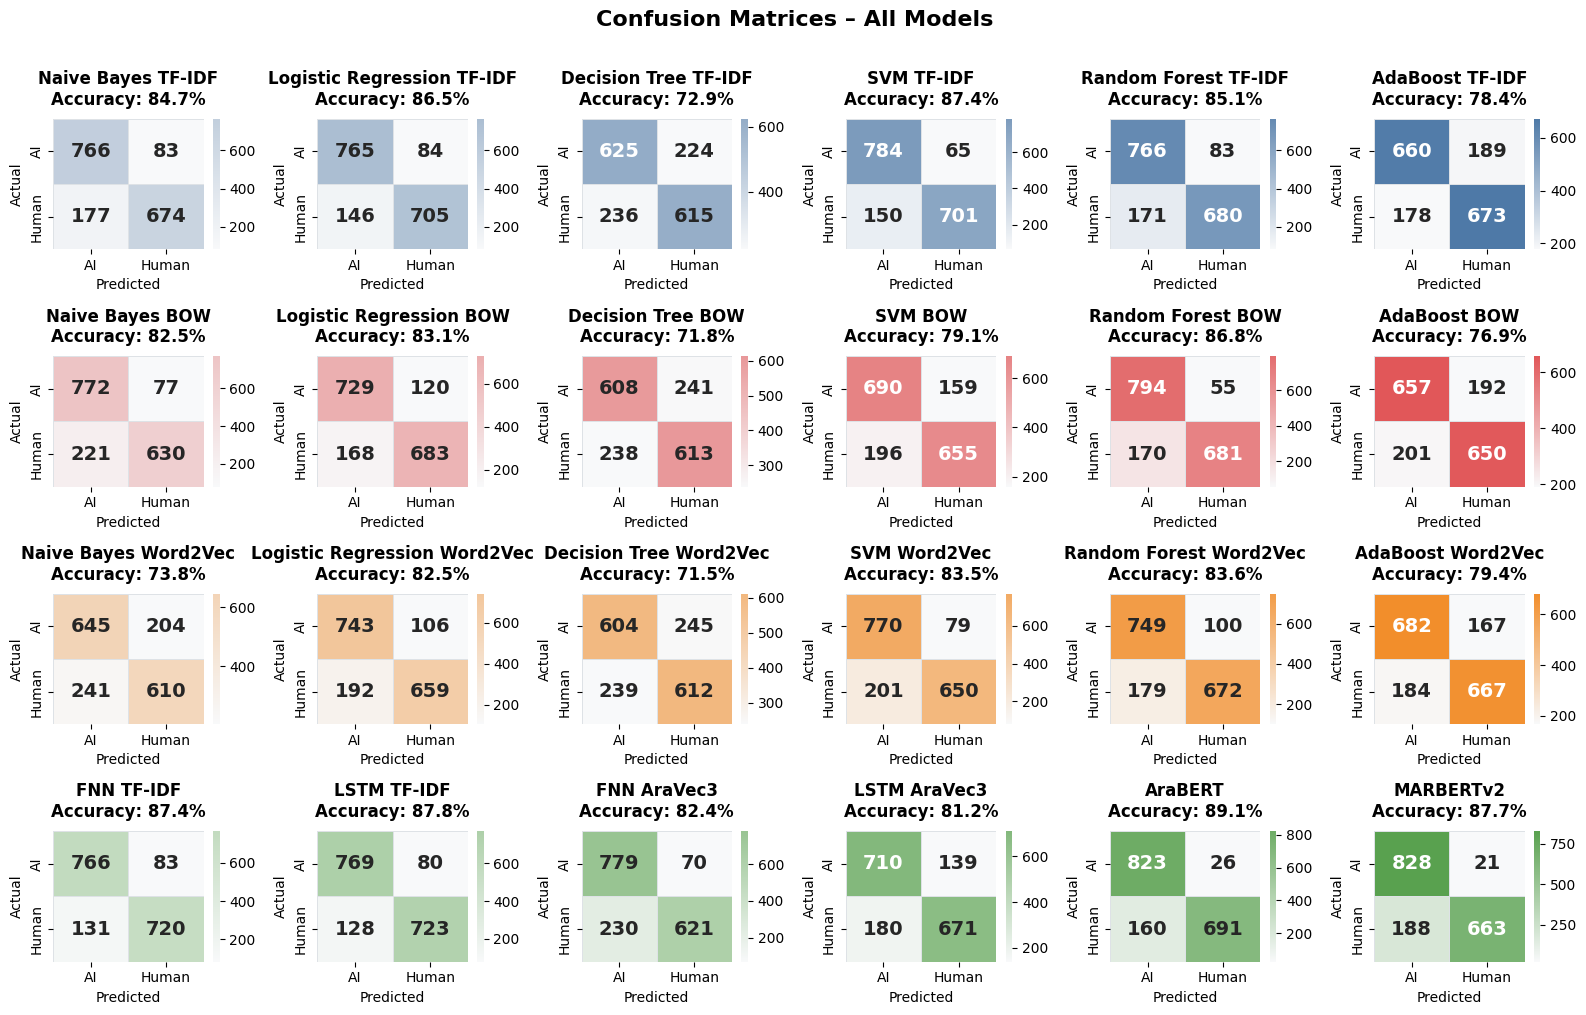

In [94]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.base import clone
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import seaborn as sns

fig, axes = plt.subplots(4, 6, figsize=(16, 10))
fig.suptitle('Confusion Matrices – All Models',
             fontsize=16, fontweight='bold', y=1.01)

for ax, mname in zip(axes.flat, MODELS6.keys()):
    cm = confusion_matrix(y6, model_preds6[mname])
    acc = accuracy_score(y6, model_preds6[mname])
    color = model_colors6[mname]
    cmap = LinearSegmentedColormap.from_list('custom', ['#f8f9fa', color])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=['AI', 'Human'], yticklabels=['AI', 'Human'],
                ax=ax, linewidths=0.5, linecolor='#dee2e6',
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f'{mname}\nAccuracy: {acc:.1%}', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

/tmp/ipykernel_4847/4147403858.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(heat_df6.applymap(lambda x: f'{x:.1%}'))


,SVM TF-IDF,Random Forest BOW,Logistic Regression TF-IDF,Decision Tree TF-IDF,Naive Bayes TF-IDF,AdaBoost Word2Vec,FNN TF-IDF,LSTM TF-IDF,FNN AraVec3,LSTM AraVec3,AraBERT,MARBERTv2
Source,,,,,,,,,,,,
Self Written,80.6%,79.1%,83.1%,68.9%,79.1%,81.8%,81.8%,84.1%,79.1%,83.6%,79.9%,74.1%
Al Jazeera,84.8%,83.4%,83.4%,75.5%,81.5%,80.1%,87.4%,85.4%,70.2%,77.5%,81.5%,77.5%
Mawdoo3,88.9%,80.0%,84.4%,78.9%,80.0%,72.2%,88.9%,87.8%,61.1%,71.1%,84.4%,82.2%
Roya News,83.0%,79.2%,79.2%,84.9%,77.4%,67.9%,88.7%,88.7%,56.6%,60.4%,84.9%,84.9%
BBC Arabic,83.8%,86.5%,86.5%,83.8%,83.8%,81.1%,89.2%,86.5%,75.7%,81.1%,81.1%,89.2%
Al Arabiya,87.1%,80.6%,83.9%,71.0%,80.6%,74.2%,87.1%,90.3%,74.2%,80.6%,93.5%,90.3%
Sky News Arabia,87.5%,79.2%,87.5%,70.8%,87.5%,87.5%,87.5%,87.5%,75.0%,83.3%,95.8%,95.8%
ChatGPT,92.3%,95.3%,90.9%,75.2%,93.1%,79.9%,89.1%,91.2%,90.1%,82.5%,96.7%,97.4%
Gemini,93.2%,92.7%,91.6%,71.2%,87.4%,82.2%,91.6%,90.1%,92.7%,86.4%,99.0%,99.5%


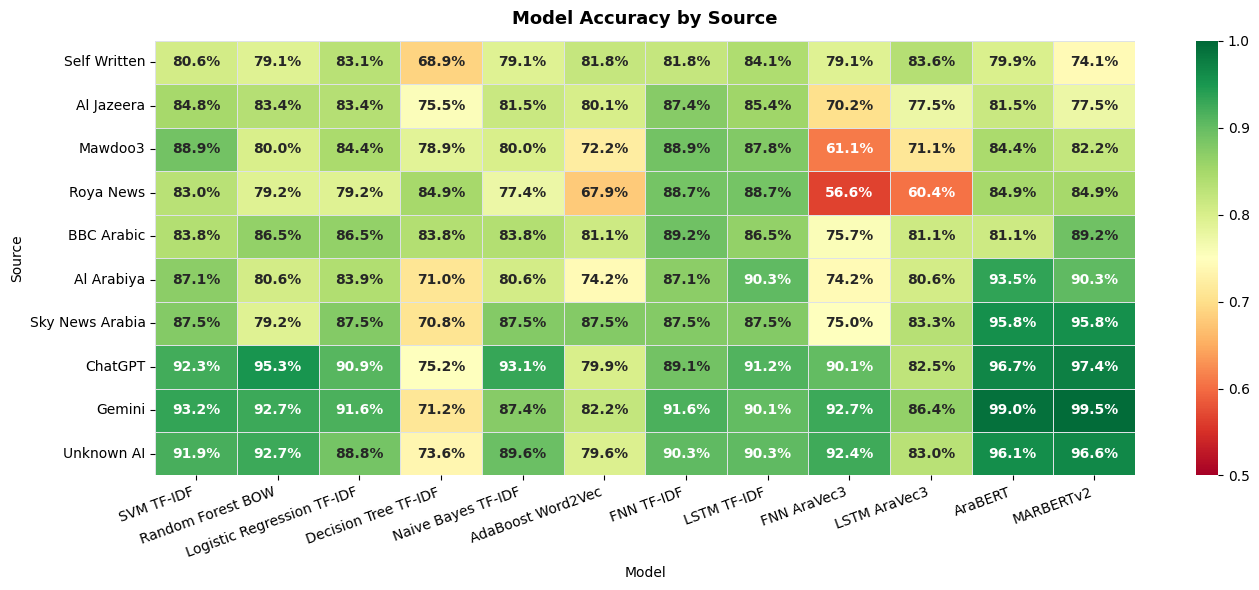

In [109]:
df_eval = pd.read_csv('merged_dataset.csv')
df_eval['text_norm'] = df_eval['text'].apply(preprocess)
df_eval = df_eval[df_eval['text_norm'].str.strip().str.len() > 10].reset_index(drop=True)
df_eval.drop_duplicates(subset=['text_norm'], inplace=True)
df_eval.reset_index(drop=True, inplace=True)
y6  = le.fit_transform(df_eval['label'])
df_eval['y_true'] = y6
Best_models = ['SVM TF-IDF', 'Random Forest BOW', 'Logistic Regression TF-IDF', 'Decision Tree TF-IDF', 'Naive Bayes TF-IDF', 'AdaBoost Word2Vec',
               'FNN TF-IDF', 'LSTM TF-IDF', 'FNN AraVec3', 'LSTM AraVec3', 'AraBERT', 'MARBERTv2',]
for mname in Best_models:
    df_eval[mname] = model_preds6[mname]

SOURCES6 = ['Self Written', 'Al Jazeera', 'Mawdoo3', 'Roya News',
                  'BBC Arabic', 'Al Arabiya', 'Sky News Arabia',
                  'ChatGPT', 'Gemini', 'Unknown AI']

rows_h = []
for src in SOURCES6:
    mask = df_eval['source'] == src
    sub  = df_eval[mask]
    row  = {'Source': src}
    for m in Best_models:
        row[m] = accuracy_score(sub['y_true'], sub[m])
    rows_h.append(row)

heat_df6 = pd.DataFrame(rows_h).set_index('Source')
display(heat_df6.applymap(lambda x: f'{x:.1%}'))

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heat_df6, annot=True, fmt='.1%', cmap='RdYlGn',
            vmin=0.5, vmax=1.0, linewidths=0.5, linecolor='#dee2e6',
            ax=ax, annot_kws={'size': 10, 'weight': 'bold'})
ax.set_title('Model Accuracy by Source', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Model'); ax.set_ylabel('Source')
plt.xticks(rotation=20, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()
